# Function Enrichment Analysis 

## Data Processing for Known Enzyme Universe

In [1]:
def get_pLDDT(pdb_p):
    infile = open(pdb_p,'r')
    pLDDT = []
    for line in infile:
          if line[0:6].rstrip() == 'ATOM' and line[13:15].rstrip() == 'CA':
            pLDDT.append(float(line[60:65].rstrip()))
    infile.close()
    return np.mean(pLDDT)

In [12]:
from CLEAN.utils import *
dirs = "/Users/eth-may/Desktop/dtu/semester7/Thesis/tttianhao-CLEAN-0cf2cac/"
id_ec, ec_id =  get_ec_id_dict(dirs+'data/split100' + '.csv')

In [2]:
file3 = '/Users/eth-may/Desktop/dtu/semester7/Thesis/data/all/all_cluster.tsv'
file4 = '/Users/eth-may/Desktop/dtu/semester7/Thesis/data/all/afall_ID50_cluster.tsv'
file5 = '/Users/eth-may/Desktop/dtu/semester7/Thesis/data/all/select_cluster.tsv'

In [3]:
rep_seq = {}
rep_fold = {}
seqfile = open(file3,'r')
for line in seqfile:
    key = line.split('\t')[0]
    if key in rep_seq.keys():
        rep_seq[key].append(line.split('\t')[1].split('\n')[0])
    else:
        rep_seq[key] = []
        rep_seq[key].append(line.split('\t')[1].split('\n')[0])
        
foldfile = open(file5,'r')
for line in foldfile:
    key = line.split('\t')[0].split('.')[0]
    if key in rep_fold.keys():
        rep_fold[key].append(line.split('\t')[1].split('.')[0])
    else:
        rep_fold[key] = []
        rep_fold[key].append(line.split('\t')[1].split('.')[0])

In [4]:
import os
import numpy as np
af_path = '/Users/eth-may/Desktop/dtu/semester7/Thesis/data/afall/'
af_list = os.listdir(af_path)
rep_structure = []
rep_pLDDT = []
keys = []
for key in rep_seq.keys():
    pLDDTs = []
    items = []
    for item in rep_seq[key]:
        item_name = item + '.pdb'
        if item_name in af_list:
            pdb_p = af_path+ item + '.pdb'
            pLDDTs.append(get_pLDDT(pdb_p))
            items.append(item)
    if len(pLDDTs)>0:
        max_plddt = max(pLDDTs)
        rep_pLDDT.append(max_plddt)
        rep_structure.append(items[pLDDTs.index(max_plddt)])
        keys.append(key)

In [5]:
threshold_value = 90 
positions = [index for index, value in enumerate(rep_pLDDT) if value > threshold_value]

sel_struc=[rep_structure[index ]for index in positions]
sel_keys = [keys[index ]for index in positions]


In [6]:
fun_fold = {}
sort_items = []
sel_seq = {}
for key in rep_fold.keys():
    fun_fold[key] = []
    
    for item in rep_fold[key]:
        if item in sel_struc:
            k = sel_keys[sel_struc.index(item)]
            fun_fold[key].extend(rep_seq[k])
            sel_seq[k] = rep_seq[k]
        
            sort_items.extend(rep_seq[k])
        #print(key,item,len(sort_items))
        if item not in sel_struc and len(rep_fold[key])==1:
            fun_fold[key].append(key)
            sort_items.append(key)

In [7]:
sel_seq = {}
for item in sel_struc:
    k = sel_keys[sel_struc.index(item)]
    sel_seq[k] = rep_seq[k]
    
members = []
keys = []
for key in sel_seq.keys():
    keys.append(key)
    members.append(len(sel_seq[key]))
    
sing_seq = [keys[index] for index, value in enumerate(members) if value == 1]

In [8]:
members = []
keys = []
for key in rep_fold.keys():
    keys.append(key)
    members.append(len(rep_fold[key]))
sing_fold = [keys[index] for index, value in enumerate(members) if value == 1]

In [9]:
members = []
keys = []
for key in fun_fold.keys():
    keys.append(key)
    members.append(len(fun_fold[key]))
sing_funfold = [keys[index] for index, value in enumerate(members) if value == 1]

## EC Consistent Analysis

In [13]:
fun_check = {}
fun_key = {}
fold_index = []
fold_items = []
for key in fun_fold.keys():
    fun_key[key] = id_ec[key]
    fun_check[key]= []
    for item in fun_fold[key]:
        fun_check[key].append(id_ec[item])
        fold_index.append(key)
        fold_items.append(item)

fun_clu = {}
for key in ec_id.keys():
    fun_clu[key] = []
    for item in ec_id[key]:
        if item in fold_items:
            fun_clu[key].append(fold_index[fold_items.index(item)])
    if len(fun_clu[key]) == 0:
        fun_clu.pop(key, None)


uni_fold = []
for key in fun_clu.keys():
    list_of_lists=fun_clu[key]
    uni_fold.append(all(sublist == list_of_lists[0] for sublist in list_of_lists))
    
uni_fun = []
for key in fun_check.keys():
    list_of_lists=fun_check[key]
    uni_fun.append(all(sublist == list_of_lists[0] for sublist in list_of_lists))
    

In [14]:
fun_check_fold = {}
fun_key_fold = {}
fold_index_fold = []
fold_items_fold = []
for key in rep_fold.keys():
    fun_key_fold[key] = id_ec[key]
    fun_check_fold[key]= []
    for item in rep_fold[key]:
        fun_check_fold[key].append(id_ec[item])
        fold_index_fold.append(key)
        fold_items_fold.append(item)

uni_fun_fold = []
for key in fun_check_fold.keys():
    list_of_lists=fun_check_fold[key]
    uni_fun_fold.append(all(sublist == list_of_lists[0] for sublist in list_of_lists))

In [15]:
members = []
keys = []
for key in fun_clu.keys():
    keys.append(key)
    members.append(len(fun_clu[key]))
sing_fold_fun = [keys[index] for index, value in enumerate(members) if value == 1]

In [16]:
keys = []
for key in fun_check_fold.keys():
    keys.append(key)

uni_fun_fold_keys = []
uni_nofun_fold_keys = []
for i in range(len(keys)):
    if uni_fun_fold[i]:
        uni_fun_fold_keys.append(keys[i])
    else:
        uni_nofun_fold_keys.append(keys[i])

for item in rep_fold[key]:
    if item in sel_struc:
            k = sel_keys[sel_struc.index(item)]
            fun_fold[key].extend(rep_seq[k])

In [17]:
def is_consistent(cluster):
    ECs = []
    uni_fun_clu = []
    for item in cluster:
        ECs.append(id_ec[item])
    
    return all(sublist == ECs[0] for sublist in ECs)

In [18]:
uni_fun_seq = []
for key in rep_seq.keys():
    ECs = []
    for item in rep_seq[key]:
        ECs.append(id_ec[item])
    if all(sublist == ECs[0] for sublist in ECs):
        uni_fun_seq.append(key)
        
cluster = rep_seq['C5C9S6']
ECs = []
uni_fun_clu = []
for item in cluster:
    ECs.append(id_ec[item])
uni_fun_clu.append(all(sublist == ECs[0] for sublist in ECs))

for key in uni_nofun_fold_keys:
    items = []
    for item in rep_fold[key]:
        if item in sel_struc:
            k = sel_keys[sel_struc.index(item)]
            if is_consistent(rep_seq[k]):
                items.append(item)



In [19]:
keys = []
for key in fun_check_fold.keys():
    keys.append(key)
    
uni_fun_clu_key_fold = [keys[i] for i in range(len(uni_fun)) if uni_fun_fold[i]]


uni_fun_clu_key_nsingle_fold = []
for item in uni_fun_clu_key_fold:
    if item not in sing_fold:
        uni_fun_clu_key_nsingle_fold.append(item)

members = []
keys = []
for key in fun_fold.keys():
    keys.append(key)
    members.append(len(fun_fold[key]))
uni_fun_true_size =[members[i] for i in range(len(uni_fun)) if uni_fun[i] ]
uni_fun_False_size =[members[i] for i in range(len(uni_fun)) if uni_fun[i]==False]

uni_fun_true_key = [keys[i] for i in range(len(uni_fun)) if uni_fun[i] ]
uni_fun_False_key = [keys[i] for i in range(len(uni_fun)) if uni_fun[i]==False]

In [20]:
EC_num = []
for item in uni_fun_true_key:
    EC_num.append(len(set(np.array(fun_check[item]).flatten())))

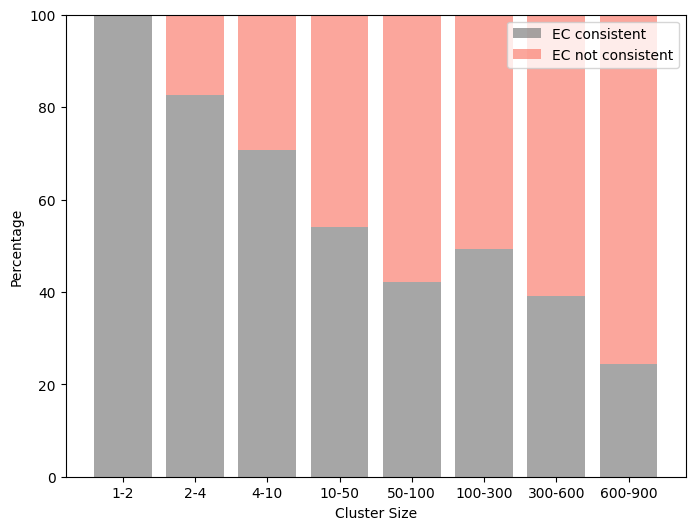

In [21]:
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

def cluster_size_count(your_list):
    counter = Counter(your_list)
    segment_counts = {segment: 0 for segment in segments}
    for element, count in counter.items():
        for segment in segments:
            if segment[0] <= element < segment[1]:
                segment_counts[segment] += count
    return segment_counts


segments = [(1, 2), (2, 4), (4, 10), (10, 50), (50, 100), (100, 300), (300, 600), (600, 900)]
counts_fold = cluster_size_count(uni_fun_true_size)
counts_fli = cluster_size_count(uni_fun_False_size)



percentages_fold = {segment: (count / (count+counts_fli[segment])) * 100 for segment, count in counts_fold.items()}
percentages_fli = {segment: (count / (count+counts_fold[segment])) * 100 for segment, count in counts_fli.items()}


fold_percentages = np.array(list(percentages_fold.values()))
fli_percentages = np.array(list(percentages_fli.values()))


plt.figure(figsize=(8, 6))
plt.bar(range(len(segments)), fold_percentages, color='gray', alpha=0.7, label='EC consistent', tick_label=[f"{segment[0]}-{segment[1]}" for segment in segments])
plt.bar(range(len(segments)), fli_percentages, bottom=fold_percentages, color='salmon', alpha=0.7, label='EC not consistent')

plt.xlabel('Cluster Size')
plt.ylabel('Percentage')
plt.legend()
plt.show()


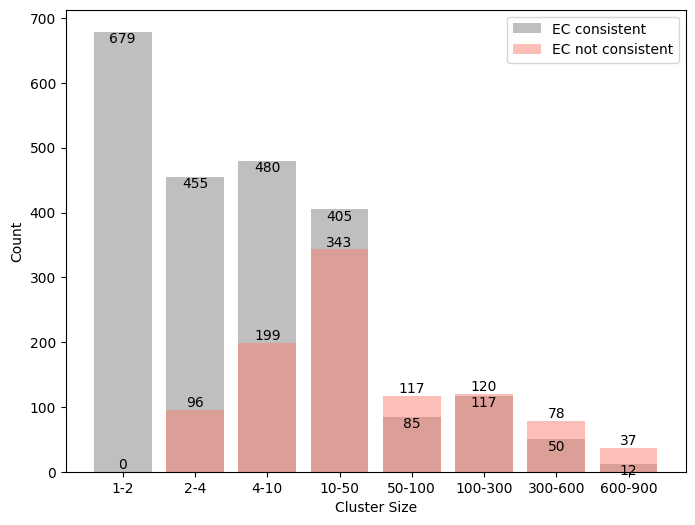

In [22]:
import matplotlib.pyplot as plt
from collections import Counter

segments = [(1,2),(2, 4), (4, 10), (10, 50), (50, 100),(100, 300),(300, 600),(600, 900)]

def cluster_size_count(your_list):

    counter = Counter(your_list)
    #segments = [(50, 100),(100, 200),(200, 350),(350, 500),(500, 700),(700, 900)]

    segment_counts = {segment: 0 for segment in segments}

    for element, count in counter.items():
        for segment in segments:
            if segment[0] <= element < segment[1]:
                segment_counts[segment] += count
    return segment_counts

_,  counts_fold = zip(*cluster_size_count(uni_fun_true_size).items())
_,  counts_fli = zip(*cluster_size_count(uni_fun_False_size).items())

plt.figure(figsize=(8, 6))
bars_fold = plt.bar(range(len(segments)), counts_fold,color='gray', alpha=0.5,label='EC consistent', tick_label=[f"{segment[0]}-{segment[1]}" for segment in segments])
bars_fli = plt.bar(range(len(segments)), counts_fli,color='salmon', alpha=0.5,label='EC not consistent' , tick_label=[f"{segment[0]}-{segment[1]}" for segment in segments])

plt.xlabel('Cluster Size')
plt.ylabel('Count')
#plt.title('Segmented Counts')
plt.grid(False)
for bar in bars_fold:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval, round(yval, 2), ha='center', va='top')
for bar in bars_fli:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval, round(yval, 2), ha='center', va='bottom')
plt.legend()
plt.show()

## GO Enrichment Analysis

### Input Data Preparation

In [23]:
file1 = '/Users/eth-may/Desktop/dtu/semester7/Thesis/data/uniprotkb_AND_reviewed_true_2023_07_03.tsv'
file3 = '/Users/eth-may/Desktop/dtu/semester7/Thesis/data/all/all_cluster.tsv'
file4 = '/Users/eth-may/Desktop/dtu/semester7/Thesis/data/all/afall_ID50_cluster.tsv'
file5 = '/Users/eth-may/Desktop/dtu/semester7/Thesis/data/all/select_cluster.tsv'
from CLEAN.utils import *
dirs = "/Users/eth-may/Desktop/dtu/semester7/Thesis/tttianhao-CLEAN-0cf2cac/"
id_ec, ec_id =  get_ec_id_dict(dirs+'data/split100' + '.csv')

In [24]:
import pandas as pd
GO_table = pd.read_csv(file1, sep='\t')
GO_table

,Entry,Reviewed,Entry Name,Protein names,Gene Names,Organism,Length,Gene Ontology (biological process),Gene Ontology (cellular component),Gene Ontology (molecular function),Gene Ontology (GO),EC number,Sequence,Date of creation,Gene3D,Pfam
0,A0A009IHW8,reviewed,ABTIR_ACIB9,2' cyclic ADP-D-ribose synthase AbTIR (2'cADPR...,J512_3302,Acinetobacter baumannii (strain 1295743),269,NAD catabolic process [GO:0019677]; signal tra...,NaN,NAD(P)+ nucleosidase activity [GO:0050135]; NA...,NAD(P)+ nucleosidase activity [GO:0050135]; NA...,3.2.2.-; 3.2.2.6,MSLEQKKGADIISKILQIQNSIGKTTSPSTLKTKLSEISRKEQENA...,2020-02-26,3.40.50.10140;,PF13676;
1,A0A023I7E1,reviewed,ENG1_RHIMI,"Glucan endo-1,3-beta-D-glucosidase 1 (Endo-1,3...",ENG1 LAM81A,Rhizomucor miehei,796,cell wall organization [GO:0071555]; polysacch...,extracellular region [GO:0005576],"glucan endo-1,3-beta-D-glucosidase activity [G...",extracellular region [GO:0005576]; glucan endo...,3.2.1.39,MRFQVIVAAATITMITSYIPGVASQSTSDGDDLFVPVSNFDPKSIF...,2022-12-14,1.10.287.1170;1.20.5.420;,PF17652;PF03639;
2,A0A024B7W1,reviewed,POLG_ZIKVF,Genome polyprotein [Cleaved into: Capsid prote...,NaN,Zika virus (isolate ZIKV/Human/French Polynesi...,3423,clathrin-dependent endocytosis of virus by hos...,centrosome [GO:0005813]; extracellular region ...,"4 iron, 4 sulfur cluster binding [GO:0051539];...",centrosome [GO:0005813]; extracellular region ...,2.1.1.56; 2.1.1.57; 2.7.7.48; 3.4.21.91; 3.6.1...,MKNPKKKSGGFRIVNMLKRGVARVSPFGGLKRLPAGLLLGHGPIRM...,2018-01-31,1.10.10.930;1.10.260.90;1.20.1280.260;2.40.10....,PF01003;PF07652;PF02832;PF00869;PF01004;PF0094...
3,A0A024SC78,reviewed,CUTI1_HYPJR,Cutinase (EC 3.1.1.74),M419DRAFT_76732,Hypocrea jecorina (strain ATCC 56765 / BCRC 32...,248,NaN,extracellular region [GO:0005576],cutinase activity [GO:0050525],extracellular region [GO:0005576]; cutinase ac...,3.1.1.74,MRSLAILTTLLAGHAFAYPKPAPQSVNRRDWPSINEFLSELAKVMP...,2022-05-25,3.40.50.1820;,PF01083;
4,A0A024SH76,reviewed,GUX2_HYPJR,"Exoglucanase 2 (EC 3.2.1.91) (1,4-beta-cellobi...",cbh2 M419DRAFT_122470,Hypocrea jecorina (strain ATCC 56765 / BCRC 32...,471,cellulose catabolic process [GO:0030245],extracellular region [GO:0005576],"cellulose 1,4-beta-cellobiosidase activity [GO...",extracellular region [GO:0005576]; cellulose 1...,3.2.1.91,MIVGILTTLATLATLAASVPLEERQACSSVWGQCGGQNWSGPTCCA...,2017-08-30,3.20.20.40;,PF00734;PF01341;
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
569788,W6JGV7,reviewed,REP_CPBDV,Replication-associated protein (Rep) (Viral pr...,NaN,Chaetoceros protobacilladnavirus 2 (Chaetocero...,484,DNA replication [GO:0006260]; viral DNA genome...,host cell nucleus [GO:0042025],NaN,host cell nucleus [GO:0042025]; DNA replicatio...,NaN,MSAPLSIEQDDLLTDDLKSWLSDIDFSNDNEEAIEMEPSDIEMSSP...,2018-11-07,3.40.1310.20;,NaN
569789,W6JHZ8,reviewed,VP1_CPBDV,Viral protein 1 (VP1),NaN,Chaetoceros protobacilladnavirus 2 (Chaetocero...,210,NaN,NaN,NaN,NaN,NaN,MNVKGASDKAQLAMQAEWEEVLAPEGALAVEEASSVLKISDDERRS...,2018-11-07,NaN,NaN
569790,W6JQK2,reviewed,YBW7_SCHPO,Uncharacterized protein SPBC651.07,SPBC651.07,Schizosaccharomyces pombe (strain 972 / ATCC 2...,268,NaN,NaN,NaN,NaN,NaN,MIVIEPTILYEAAALYTRYTANGGDSNDVVALLVGPIVQTLSIPSS...,2015-10-14,NaN,NaN
569791,X6R8D5,reviewed,GUCNB_HUMAN,Putative uncharacterized protein GUCA1ANB (GUC...,GUCA1ANB,Homo sapiens (Human),127,NaN,NaN,NaN,NaN,NaN,MGRKEHESPSQPHMCGWEDSQKPSVPSHGPKTPSCKGVKAPHSSRP...,2020-12-02,NaN,NaN


In [25]:
GO_table[GO_table['Entry']=='A0A009IHW8']['Gene Ontology (GO)'].values.tolist()

['NAD(P)+ nucleosidase activity [GO:0050135]; NAD+ nucleosidase activity [GO:0003953]; NAD+ nucleotidase, cyclic ADP-ribose generating [GO:0061809]; NAD catabolic process [GO:0019677]; signal transduction [GO:0007165]']

In [26]:
GO_dic = {}

# Iterate over each row in the DataFrame
for index, row in GO_table.iterrows():
    entry = row['Entry']
    go_terms = row['Gene Ontology (GO)']
    
    # Check if the GO terms are not NaN (missing)
    if not pd.isna(go_terms):
        # Split the GO terms and store them in the dictionary
        GO_dic[entry] = [term.strip() for term in go_terms.split(';')]

In [27]:
fun_GO = {}
for key in fun_fold.keys():
    if len(fun_fold[key])>10:
        fun_GO[key] = {}
        for item in fun_fold[key]:
            if item in GO_dic.keys():
                fun_GO[key][item]=GO_dic[item]
        if len(fun_GO[key]) == 0:
            fun_GO.pop(key, None)

In [28]:
GO_mfdic = {}

# Iterate over each row in the DataFrame
for index, row in GO_table.iterrows():
    entry = row['Entry']
    go_terms = row['Gene Ontology (molecular function)']
    
    # Check if the GO terms are not NaN (missing)
    if not pd.isna(go_terms):
        # Split the GO terms and store them in the dictionary
        GO_mfdic[entry] = [term.strip() for term in go_terms.split(';')]


In [29]:
fun_mfGO = {}
for key in fun_fold.keys():
    if len(fun_fold[key])>10:
        fun_mfGO[key] = {}
        for item in fun_fold[key]:
            if item in GO_mfdic.keys():
                fun_mfGO[key][item]=GO_mfdic[item]
        if len(fun_mfGO[key]) == 0:
            fun_mfGO.pop(key, None)

In [30]:
funF_mfGO = {}
for key in fun_fold.keys():
    if len(fun_fold[key])>10:
        
        for item in fun_fold[key]:
            if item in GO_mfdic.keys():
                funF_mfGO[item]=GO_mfdic[item]
        if len(funF_mfGO[item]) == 0:
            funF_mfGO.pop(item, None)

In [31]:
GO_ccdic = {}

# Iterate over each row in the DataFrame
for index, row in GO_table.iterrows():
    entry = row['Entry']
    go_terms = row['Gene Ontology (cellular component)']
    
    # Check if the GO terms are not NaN (missing)
    if not pd.isna(go_terms):
        # Split the GO terms and store them in the dictionary
        GO_ccdic[entry] = [term.strip() for term in go_terms.split(';')]


In [32]:
fun_ccGO = {}
for key in fun_fold.keys():
    if len(fun_fold[key])>10:
        fun_ccGO[key] = {}
        for item in fun_fold[key]:
            if item in GO_ccdic.keys():
                fun_ccGO[key][item]=GO_ccdic[item]
        if len(fun_ccGO[key]) == 0:
            fun_ccGO.pop(key, None)

In [33]:
funF_ccGO = {}
for key in fun_fold.keys():
    if len(fun_fold[key])>10:
        
        for item in fun_fold[key]:
            if item in GO_ccdic.keys():
                funF_ccGO[item]=GO_ccdic[item]
        #if len(funF_ccGO[item]) == 0:
            #funF_ccGO.pop(item, None)

In [34]:
GO_bpdic = {}

# Iterate over each row in the DataFrame
for index, row in GO_table.iterrows():
    entry = row['Entry']
    go_terms = row['Gene Ontology (biological process)']
    
    # Check if the GO terms are not NaN (missing)
    if not pd.isna(go_terms):
        # Split the GO terms and store them in the dictionary
        GO_bpdic[entry] = [term.strip() for term in go_terms.split(';')]


In [35]:
fun_bpGO = {}
for key in fun_fold.keys():
    if len(fun_fold[key])>10:
        fun_bpGO[key] = {}
        for item in fun_fold[key]:
            if item in GO_bpdic.keys():
                fun_bpGO[key][item]=GO_bpdic[item]
        if len(fun_bpGO[key]) == 0:
            fun_bpGO.pop(key, None)

In [ ]:
import h5py
data = funF_ccGO
with h5py.File('/Users/eth-may/Desktop/dtu/semester7/Thesis/data/GO_analysis/funF_ccGO.h5', 'w') as f:
    for key, inner_dict in data.items():    
        f.create_dataset(key, data=value)
        
data = funF_bpGO
with h5py.File('/Users/eth-may/Desktop/dtu/semester7/Thesis/data/GO_analysis/funF_bpGO.h5', 'w') as f:
    for key, inner_dict in data.items():    
        f.create_dataset(key, data=value)
        
data = funF_mfGO
with h5py.File('/Users/eth-may/Desktop/dtu/semester7/Thesis/data/GO_analysis/funF_mfGO.h5', 'w') as f:
    for key, inner_dict in data.items():    
        f.create_dataset(key, data=value)
        

### Output Data Analysis

In [36]:
file_BP = '/Users/eth-may/Desktop/dtu/semester7/Thesis/data/GO_analysis/BP_pro.txt'
file_MF = '/Users/eth-may/Desktop/dtu/semester7/Thesis/data/GO_analysis/MF_pro.txt'
file_CC = '/Users/eth-may/Desktop/dtu/semester7/Thesis/data/GO_analysis/CC_pro.txt'

In [37]:
data_BP = open(file_BP,'r')
GO_pro_BP = {}
GO_uni_pro_BP = {}
GO_non_pro_BP = {}
for line in data_BP:
    tem = line.split('\t')
    
    GO_pro_BP[tem[0].replace('"', '')] = float(tem[1])
    if tem[0].replace('"', '') in uni_fun_fold_keys:
        GO_uni_pro_BP[tem[0].replace('"', '')] = float(tem[1])
    else:
        GO_non_pro_BP[tem[0].replace('"', '')] = float(tem[1])
    
data_MF = open(file_MF,'r')
GO_pro_MF = {}
GO_uni_pro_MF = {}
GO_non_pro_MF = {}
for line in data_MF:
    tem = line.split('\t')
    
    GO_pro_MF[tem[0].replace('"', '')] = float(tem[1])
    if tem[0].replace('"', '') in uni_fun_fold_keys:
        GO_uni_pro_MF[tem[0].replace('"', '')] = float(tem[1])
    else:
        GO_non_pro_MF[tem[0].replace('"', '')] = float(tem[1])

data_CC = open(file_CC,'r')
GO_pro_CC = {}
GO_uni_pro_CC = {}
GO_non_pro_CC = {}
for line in data_CC:
    tem = line.split('\t')
    
    GO_pro_CC[tem[0].replace('"', '')] = float(tem[1])
    if tem[0].replace('"', '') in uni_fun_fold_keys:
        GO_uni_pro_CC[tem[0].replace('"', '')] = float(tem[1])
    else:
        GO_non_pro_CC[tem[0].replace('"', '')] = float(tem[1])


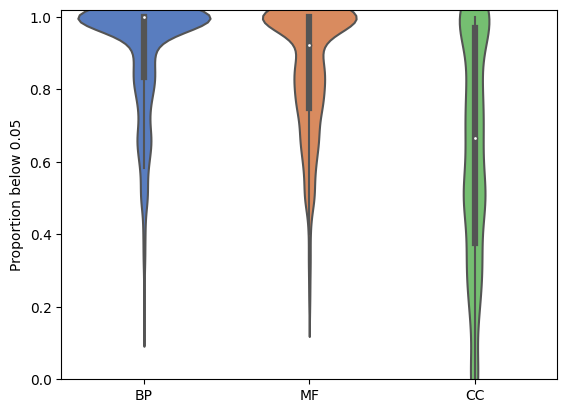

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

# 两个数据列表
data1 = list(GO_pro_BP.values())
data2 = list(GO_pro_MF.values())
data3 = list(GO_pro_CC.values())
# 使用 Seaborn 绘制两个响铃图在同一个图上
ax = sns.violinplot(data=[data1, data2,data3], palette="muted", orient='v')

#plt.title('Significant GO Enrichment Proportion across Clusters')
#plt.xlabel('Density')
plt.ylabel('Proportion below 0.05')
plt.grid(False)
# 设置 x 轴的刻度和标签
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(['BP', 'MF','CC'])
ax.set_ylim(0, 1.02) 
#plt.xticks(rotation=15)
plt.show()

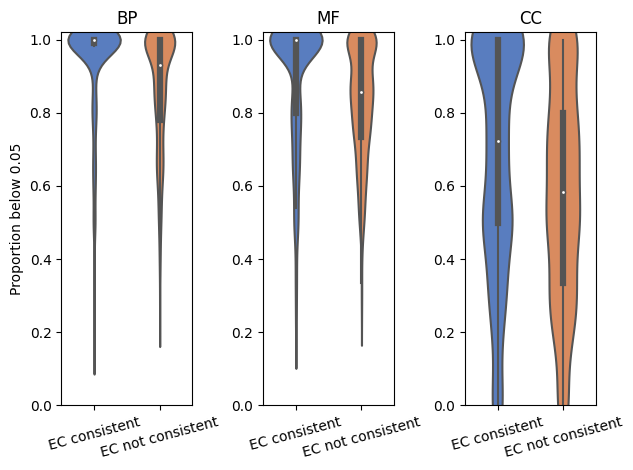

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

# 分组数据
data_group1 = [list(GO_uni_pro_BP.values()), list(GO_non_pro_BP.values())]
data_group2 = [list(GO_uni_pro_MF.values()), list(GO_non_pro_MF.values())]
data_group3 = [list(GO_uni_pro_CC.values()), list(GO_non_pro_CC.values())]

# 创建一个包含3个子图的图
fig, axes = plt.subplots(1, 3)
titles = ['BP','MF','CC']
# 绘制每个子图的小提琴图
for i, data_group in enumerate([data_group1, data_group2, data_group3]):
    ax = sns.violinplot(data=data_group, palette="muted", orient='v', ax=axes[i])
    #ax.set_xlabel('Proportion below 0.05')
    #ax.set_ylabel('Groups')
    ax.grid(False)
    ax.set_xticklabels(['EC consistent', 'EC not consistent'])
    ax.set_xticklabels(ax.get_xticklabels(), rotation=15) 
    #ax.set_yticks([0, 1])
    #ax.set_yticklabels(['Group 1', 'Group 2'])
    ax.set_title(titles[i]) 
    ax.set_ylim(0, 1.02) 
ax=axes[0]
ax.set_ylabel('Proportion below 0.05')
# 调整子图之间的间距
plt.tight_layout()

plt.show()


In [40]:
file_lenBP = '/Users/eth-may/Desktop/dtu/semester7/Thesis/data/GO_analysis/BPlen_pro.txt'
file_lenMF = '/Users/eth-may/Desktop/dtu/semester7/Thesis/data/GO_analysis/MFlen_pro.txt'
file_lenCC = '/Users/eth-may/Desktop/dtu/semester7/Thesis/data/GO_analysis/CClen_pro.txt'

In [41]:
data_BP = open(file_lenBP,'r')
GO_pro_BP = {}
GO_uni_pro_BP = {}
GO_non_pro_BP = {}
for line in data_BP:
    tem = line.split('\t')
    
    GO_pro_BP[tem[0].replace('"', '')] = float(tem[1])
    if tem[0].replace('"', '') in uni_fun_fold_keys:
        GO_uni_pro_BP[tem[0].replace('"', '')] = float(tem[1])
    else:
        GO_non_pro_BP[tem[0].replace('"', '')] = float(tem[1])
    
data_MF = open(file_lenMF,'r')
GO_pro_MF = {}
GO_uni_pro_MF = {}
GO_non_pro_MF = {}
for line in data_MF:
    tem = line.split('\t')
    
    GO_pro_MF[tem[0].replace('"', '')] = float(tem[1])
    if tem[0].replace('"', '') in uni_fun_fold_keys:
        GO_uni_pro_MF[tem[0].replace('"', '')] = float(tem[1])
    else:
        GO_non_pro_MF[tem[0].replace('"', '')] = float(tem[1])

data_CC = open(file_lenCC,'r')
GO_pro_CC = {}
GO_uni_pro_CC = {}
GO_non_pro_CC = {}
for line in data_CC:
    tem = line.split('\t')
    
    GO_pro_CC[tem[0].replace('"', '')] = float(tem[1])
    if tem[0].replace('"', '') in uni_fun_fold_keys:
        GO_uni_pro_CC[tem[0].replace('"', '')] = float(tem[1])
    else:
        GO_non_pro_CC[tem[0].replace('"', '')] = float(tem[1])


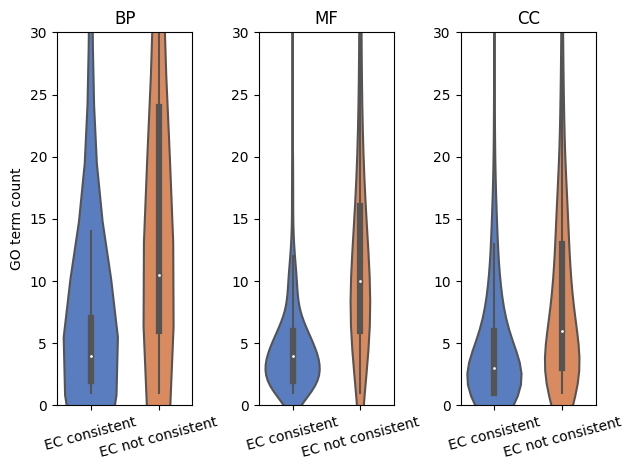

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

# 分组数据
data_group1 = [list(GO_uni_pro_BP.values()), list(GO_non_pro_BP.values())]
data_group2 = [list(GO_uni_pro_MF.values()), list(GO_non_pro_MF.values())]
data_group3 = [list(GO_uni_pro_CC.values()), list(GO_non_pro_CC.values())]

# 创建一个包含3个子图的图
fig, axes = plt.subplots(1, 3)
titles = ['BP','MF','CC']
# 绘制每个子图的小提琴图
for i, data_group in enumerate([data_group1, data_group2, data_group3]):
    ax = sns.violinplot(data=data_group, palette="muted", orient='v', ax=axes[i])
    #ax.set_xlabel('Proportion below 0.05')
    #ax.set_ylabel('Groups')
    ax.grid(False)
    ax.set_xticklabels(['EC consistent', 'EC not consistent'])
    ax.set_xticklabels(ax.get_xticklabels(), rotation=15) 
    #ax.set_yticks([0, 1])
    #ax.set_yticklabels(['Group 1', 'Group 2'])
    ax.set_ylim(0, 30)  # 添加 ylim 到所有子图中
    ax.set_title(titles[i]) 
ax=axes[0]
ax.set_ylabel('GO term count')
# 调整子图之间的间距
plt.tight_layout()

plt.show()


## Functional Embedding Analysis

In [47]:
import h5py
proVec_embfile = '/Users/eth-may/Desktop/dtu/semester7/Thesis/data/Enzyme_proteins_embed_dic'
miss_embvalue = '/Users/eth-may/Desktop/dtu/semester7/Thesis/data/Miss_proteins_embed_dic'
miss_data = ['P20894', 'A0A0U1LSP0', 'Q03498', 'Q8MU52', 'A0A140CUL9', 'W6JQJ6','B3IVI7', 'Q88QV2']
def load_proVec(lookup):
    if lookup not in miss_data:
        with h5py.File(proVec_embfile , 'r') as hf:
            dataset_name = lookup
            dataset = hf[dataset_name]


            data = dataset[:][0]
    else:
        with h5py.File(miss_embvalue , 'r') as hf:
            dataset_name = lookup
            dataset = hf[dataset_name]


            data = dataset[:][0]

    #torch_data = torch.tensor(data)
    return data #torch_data.unsqueeze(0)


def cos_sim(vector1,vector2):
    # Compute dot product
    dot_product = np.dot(vector1, vector2)

    # Compute magnitudes
    magnitude1 = np.linalg.norm(vector1)
    magnitude2 = np.linalg.norm(vector2)

    # Compute cosine similarity
    similarity = dot_product / (magnitude1 * magnitude2)
    return similarity


from sklearn.metrics.pairwise import cosine_similarity

def foldseek_clusterProvec(key):
    clusterProvec = []
    for item in fun_fold[key]:
        clusterProvec.append(load_proVec(item))
    return clusterProvec

def repfoldseek_clusterProvec(key):
    clusterProvec = []
    for item in rep_fold[key]:
        clusterProvec.append(load_proVec(item))
    return clusterProvec

def EC_clusterProvec(EC):
    clusterProvec = []
    for item in ec_id[EC]:
        clusterProvec.append(load_proVec(item))
    return clusterProvec

def cluster_cos_sim(cluster):

    # Reshape the cluster if needed
    cluster = np.array(cluster).reshape(len(cluster), -1)

    # Compute pairwise cosine similarities
    similarities = cosine_similarity(cluster)
    # 去掉对角线的值
    np.fill_diagonal(similarities, 0)
    mask = np.triu(np.ones(similarities.shape), k=1).astype(bool)
    similarities_half = similarities[mask]
    return similarities_half

def cluster_cos_sim_full(cluster):

    # Reshape the cluster if needed
    cluster = np.array(cluster).reshape(len(cluster), -1)

    # Compute pairwise cosine similarities
    similarities = cosine_similarity(cluster)
    
    return similarities

In [48]:
cluster_cos_sim_full(foldseek_clusterProvec('A1JNT5'))

array([[1.        , 0.99998623, 0.9999832 , ..., 0.9999832 , 0.9999833 ,
        0.99998677],
       [0.99998623, 1.0000002 , 0.9999953 , ..., 0.9999953 , 0.99999535,
        0.99999416],
       [0.9999832 , 0.9999953 , 0.9999999 , ..., 0.9999999 , 0.99999964,
        0.9999909 ],
       ...,
       [0.9999832 , 0.9999953 , 0.9999999 , ..., 0.9999999 , 0.99999964,
        0.9999909 ],
       [0.9999833 , 0.99999535, 0.99999964, ..., 0.99999964, 0.9999999 ,
        0.99999046],
       [0.99998677, 0.99999416, 0.9999909 , ..., 0.9999909 , 0.99999046,
        1.0000002 ]], dtype=float32)

In [49]:
case_uniFun = cluster_cos_sim_full(foldseek_clusterProvec('Q7N2V3'))
case_no_uniFun = cluster_cos_sim_full(foldseek_clusterProvec('P20921'))

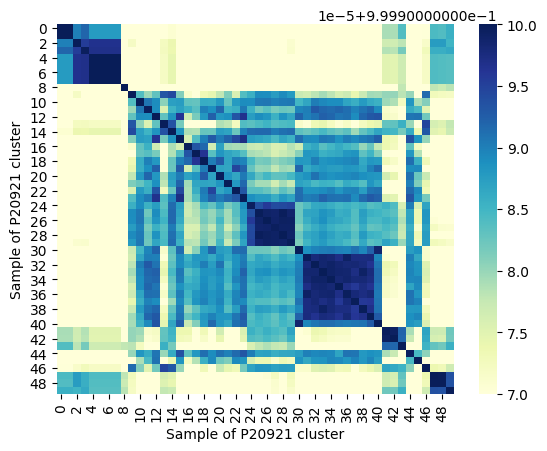

In [53]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt



# 计算余弦相似度
similarities = case_no_uniFun

# 使用seaborn绘制热图
sns.heatmap(similarities, cmap="YlGnBu", vmin=0.99997, vmax=1)
#plt.title("Cosine Similarity Heatmap")
plt.xlabel("Sample of P20921 cluster")
plt.ylabel("Sample of P20921 cluster")
plt.show()


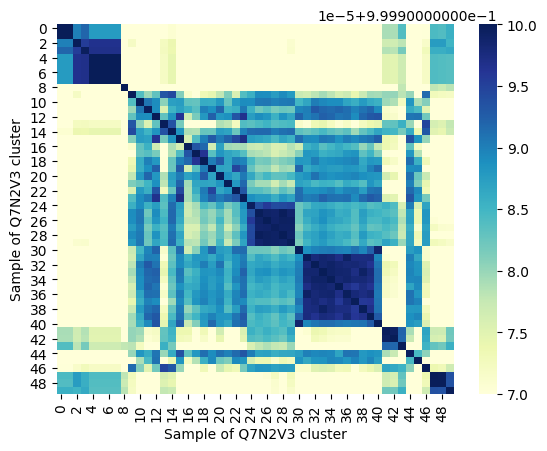

In [55]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt



# 计算余弦相似度
similarities = case_no_uniFun

# 使用seaborn绘制热图
sns.heatmap(similarities, cmap="YlGnBu", vmin=0.99997, vmax=1)
#plt.title("Cosine Similarity Heatmap")
plt.xlabel("Sample of Q7N2V3 cluster")
plt.ylabel("Sample of Q7N2V3 cluster")
plt.show()

In [56]:
fun_simfold_Prosim = {}
for key in uni_nofun_fold_keys: #fun_fold.keys():
    fun_simfold_Prosim[key] = cluster_cos_sim_full(foldseek_clusterProvec(key))

In [70]:
all_sim_W_Av = []
True_funClu_W_Av = []
False_funClu_W_Av = []

for key in fun_simfold_Prosim.keys():
    if len(fun_fold[key])>10:
        all_sim_W_Av.append(np.mean(fun_simfold_Prosim[key]))
        if key in uni_fun_clu_key_nsingle_fold:
            True_funClu_W_Av.append(np.mean(fun_simfold_Prosim[key]))
        else:
            False_funClu_W_Av.append(np.mean(fun_simfold_Prosim[key]))


In [71]:
all_sim_W_var = []
True_funClu_W_var = []
False_funClu_W_var = []

for key in fun_simfold_Prosim.keys():
    if len(fun_fold[key])>10:
        all_sim_W_var.append(np.var(fun_simfold_Prosim[key]))
        if key in uni_fun_clu_key_nsingle_fold:
            True_funClu_W_var.append(np.var(fun_simfold_Prosim[key]))
        else:
            False_funClu_W_var.append(np.var(fun_simfold_Prosim[key]))


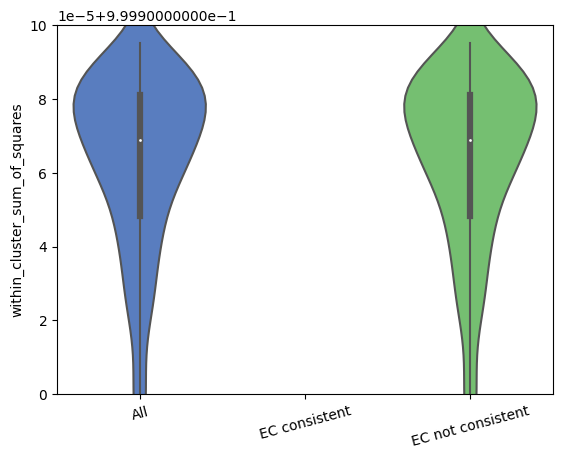

In [72]:
import seaborn as sns
import matplotlib.pyplot as plt

# 两个数据列表
data1 = all_sim_W_Av
data2 = True_funClu_W_Av 
data3 = False_funClu_W_Av
# 使用 Seaborn 绘制两个响铃图在同一个图上
ax = sns.violinplot(data=[data1, data2,data3], palette="muted", orient='v')

#plt.title('Vertical Violin Plot - Data Distribution')
#plt.xlabel('Density')
plt.ylabel('within_cluster_sum_of_squares')
plt.grid(False)
# 设置 x 轴的刻度和标签
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(['All', 'EC consistent','EC not consistent'])
plt.xticks(rotation=15)
plt.ylim(0.9999, 1) 
plt.show()